In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'IMG20250119150227.jpg', 'Classroom', 'Iktear-Hoque_232006912_AA200.3.pptx', 'CODES', '232008212 Cse124 final assignment .pdf', '232008212 Cse124 final assignment .gdoc', 'IMG20241006123907.jpg', '232006912_CSE225.pdf', 'cse 226 assignment 5.pdf', 'Share 232008212 cse225 database presentation.pptx', 'Document 10.pdf', 'Spring 25_CSE_Course Offer_regular (More Courses).docx', 'IMG20250413101854.jpg', 'Video ', 'IMG_0618 (1).jpeg', 'IMG_0618.jpeg', 'IMG_0929.jpeg', 'Graphics_final.pdf', 'Archive']


In [8]:
dataset_path = '/content/drive/MyDrive/Archive'

In [9]:
print(os.listdir(dataset_path))

['val', 'train', '__MACOSX', 'test']


In [10]:
print("Train:", os.listdir(dataset_path + '/train'))
print("Test:", os.listdir(dataset_path + '/test'))
print("Validation:", os.listdir(dataset_path + '/val'))

Train: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Test: ['NORMAL', '.DS_Store', 'PNEUMONIA']
Validation: ['PNEUMONIA', 'NORMAL']


In [11]:
import os

for folder in ['train', 'test', 'val']:

    normal_path = os.path.join(dataset_path, folder, 'NORMAL')
    pneumonia_path = os.path.join(dataset_path, folder, 'PNEUMONIA')

    normal_count = len([
        f for f in os.listdir(normal_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ])

    pneumonia_count = len([
        f for f in os.listdir(pneumonia_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ])

    print(folder)
    print("NORMAL:", normal_count)
    print("PNEUMONIA:", pneumonia_count)
    print("Total:", normal_count + pneumonia_count)
    print()

train
NORMAL: 1341
PNEUMONIA: 3881
Total: 5222

test
NORMAL: 244
PNEUMONIA: 390
Total: 634

val
NORMAL: 8
PNEUMONIA: 8
Total: 16



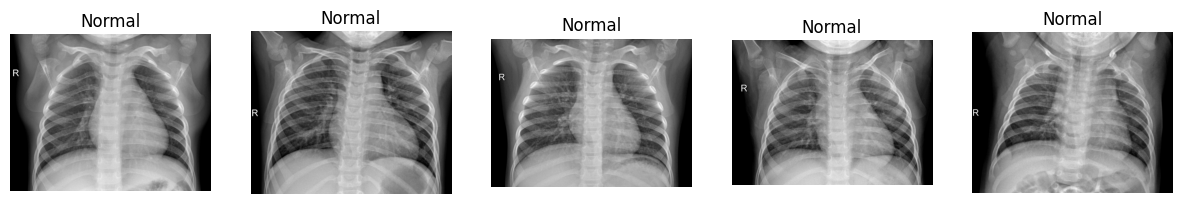

In [12]:
import matplotlib.pyplot as plt
import os
from PIL import Image

normal_path = os.path.join(dataset_path, 'train', 'NORMAL')

images = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
][:5]

plt.figure(figsize=(15, 8))

for i, image_name in enumerate(images):
    img = Image.open(os.path.join(normal_path, image_name))

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Normal')

plt.show()

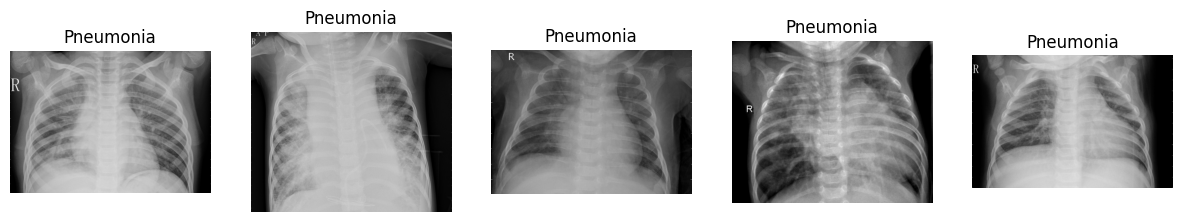

In [13]:
pneumonia_path = os.path.join(dataset_path, 'train', 'PNEUMONIA')

images = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
][:5]

plt.figure(figsize=(15, 8))

for i, image_name in enumerate(images):
    img = Image.open(os.path.join(pneumonia_path, image_name))

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Pneumonia')

plt.show()

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [15]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [16]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [18]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [19]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5222 images belonging to 2 classes.


In [20]:
val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_path, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [21]:
test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 634 images belonging to 2 classes.


In [22]:
print("Class mapping:", train_generator.class_indices)

print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Training images: 5222
Validation images: 16
Test images: 634


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [31]:
EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 3242s 20s/step - accuracy: 0.8104 - loss: 0.4321 - val_accuracy: 0.6875 - val_loss: 0.8159
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 84s 515ms/step - accuracy: 0.8954 - loss: 0.2551 - val_accuracy: 0.6875 - val_loss: 0.6515
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 83s 508ms/step - accuracy: 0.9048 - loss: 0.2257 - val_accuracy: 0.7500 - val_loss: 0.4240
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 84s 513ms/step - accuracy: 0.9171 - loss: 0.2196 - val_accuracy: 0.6875 - val_loss: 0.8440
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 82s 501ms/step - accuracy: 0.9305 - loss: 0.1849 - val_accuracy: 0.8750 - val_loss: 0.2659
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 83s 503ms/step - accuracy: 0.9378 - loss: 0.1641 - val_accuracy: 0.6250 - val_loss: 1.0349
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 83s 507ms/step - accuracy: 0.9391 - loss: 0.1588 - val_accuracy: 0.8125 - val_loss: 0.3468
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 81s 493ms/step - accuracy: 0.9414 - loss: 0

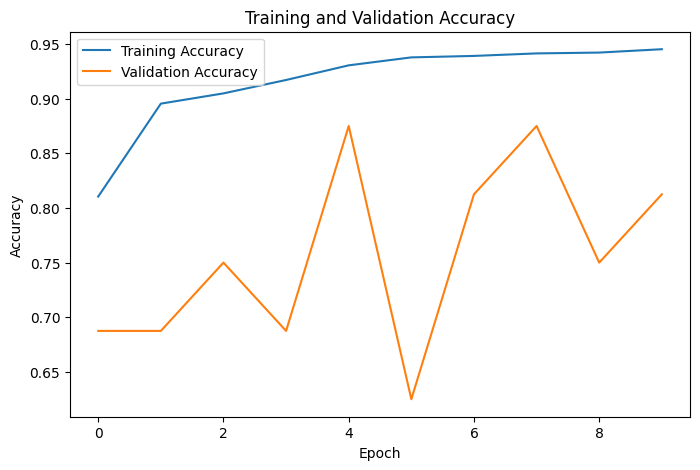

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

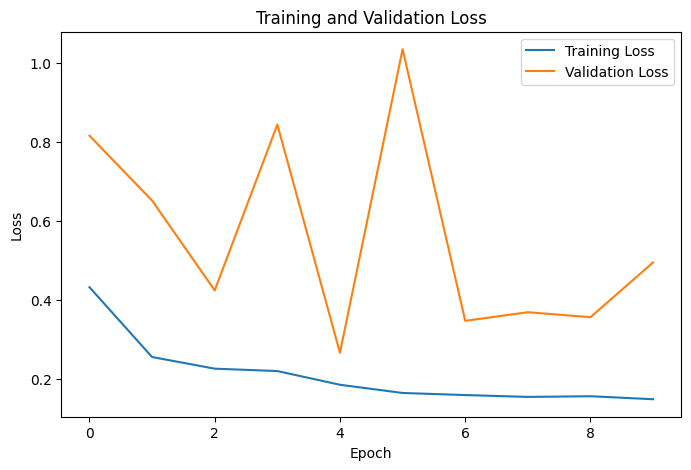

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 345s 18s/step - accuracy: 0.7697 - loss: 0.7260
Test Loss: 0.7259907126426697
Test Accuracy: 0.7697160840034485
Test Accuracy (%): 76.97160840034485


In [35]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

print("Predictions completed!")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step
Predictions completed!


In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[104 140]
 [  6 384]]


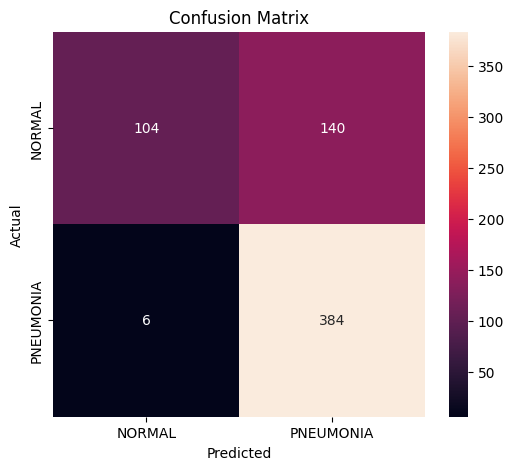

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.95      0.43      0.59       244
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       634
   macro avg       0.84      0.71      0.71       634
weighted avg       0.81      0.77      0.74       634



In [39]:
print("===== FINAL TEST RESULTS =====")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

===== FINAL TEST RESULTS =====
Test Accuracy: 76.97%
Test Loss: 0.7260

Confusion Matrix:
[[104 140]
 [  6 384]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.43      0.59       244
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       634
   macro avg       0.84      0.71      0.71       634
weighted avg       0.81      0.77      0.74       634



In [40]:
model_path = '/content/drive/MyDrive/Archive/cnn_pneumonia_model.keras'

model.save(model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/drive/MyDrive/Archive/cnn_pneumonia_model.keras


In [41]:
normal_test_path = os.path.join(
    dataset_path,
    'test',
    'NORMAL'
)

normal_images = [
    f for f in os.listdir(normal_test_path)
    if f.lower().endswith(('.jpeg', '.jpg', '.png'))
]

normal_images[:5]

['NORMAL2-IM-0246-0001-0002.jpeg',
 'NORMAL2-IM-0246-0001-0002 (1).jpeg',
 'NORMAL2-IM-0173-0001-0002.jpeg',
 'NORMAL2-IM-0123-0001.jpeg',
 'NORMAL2-IM-0033-0001.jpeg']

In [42]:
test_image_path = os.path.join(
    normal_test_path,
    normal_images[0]
)

print(test_image_path)

/content/drive/MyDrive/Archive/test/NORMAL/NORMAL2-IM-0246-0001-0002.jpeg


In [43]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    test_image_path,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    result = "PNEUMONIA"
else:
    result = "NORMAL"

print("Actual Class: NORMAL")
print("Predicted Class:", result)
print("Prediction Score:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
Actual Class: NORMAL
Predicted Class: PNEUMONIA
Prediction Score: 0.7882092


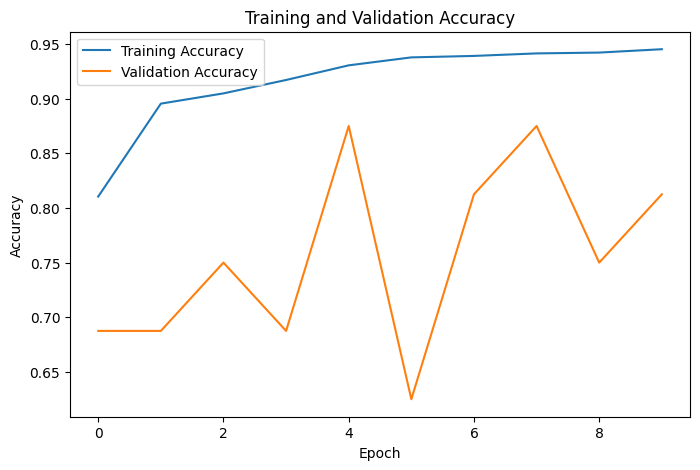

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.savefig(
    '/content/drive/MyDrive/Archive/training_validation_accuracy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

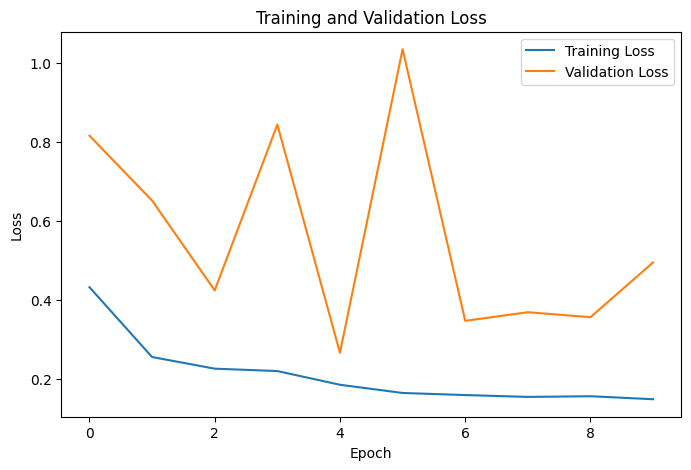

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.savefig(
    '/content/drive/MyDrive/Archive/training_validation_loss.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

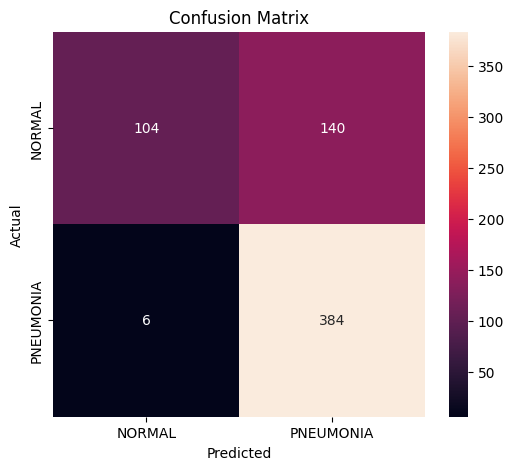

In [46]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig(
    '/content/drive/MyDrive/Archive/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()